In [352]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [353]:
#uploading dataset
df = pd.read_csv('/content/car details v4.csv')
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [354]:
df.shape

(2059, 20)

In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [356]:
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [357]:
df.isna().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [358]:
df.duplicated().sum()   # no duplicates

np.int64(0)

In [ ]:
#data visualization

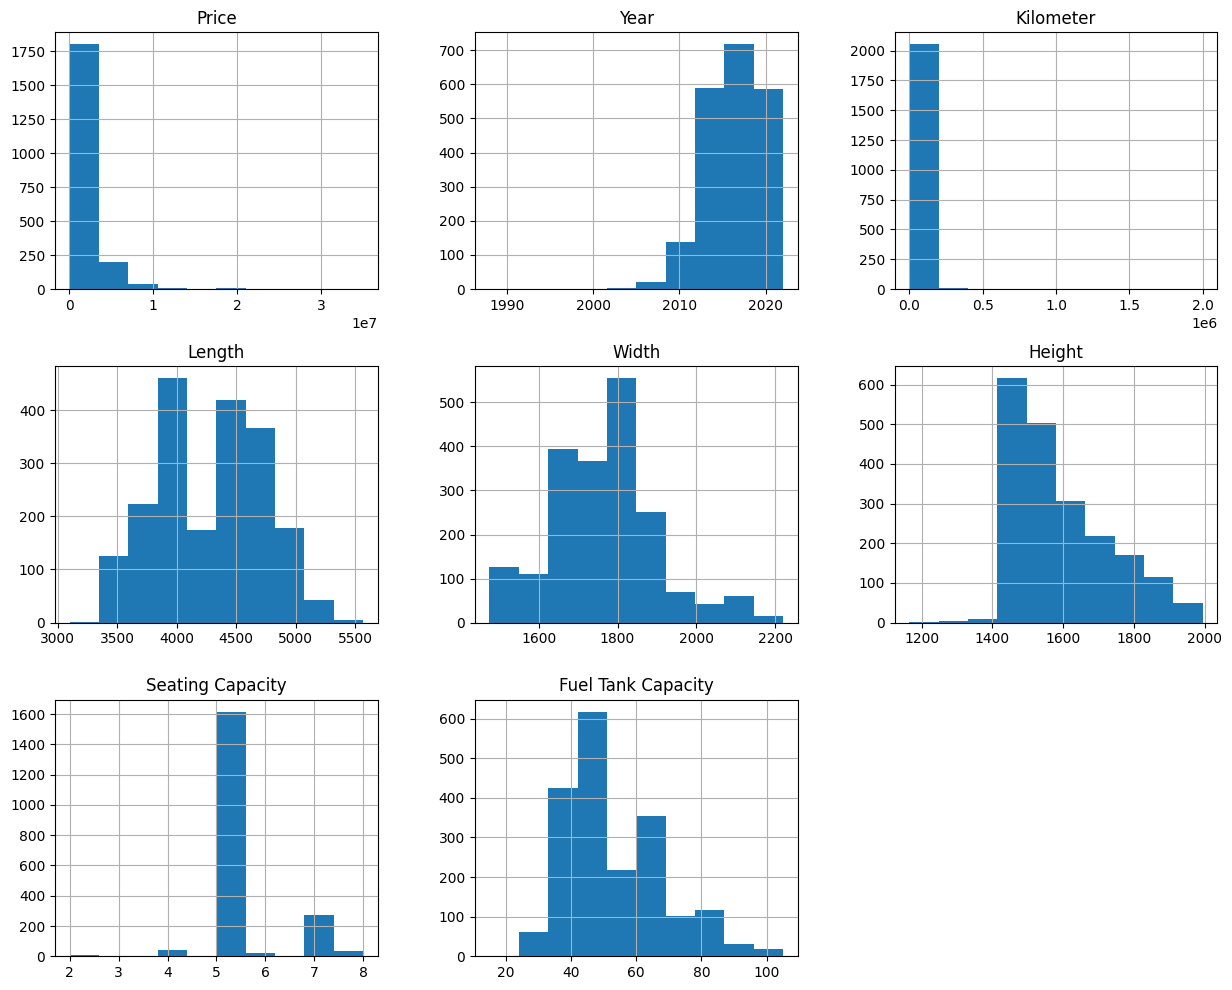

In [359]:
df.hist(figsize=(15,12))
plt.show()

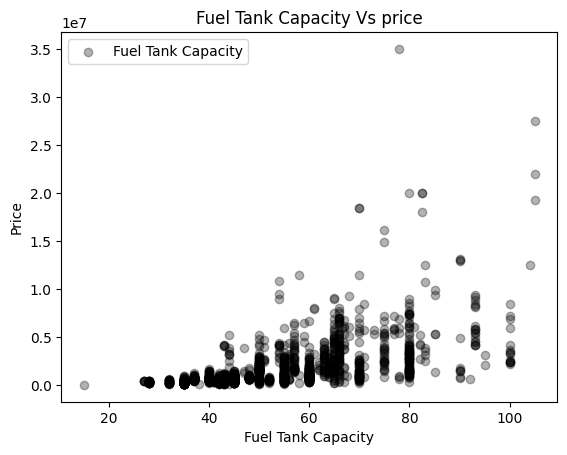

In [360]:
plt.scatter(x=df['Fuel Tank Capacity'],y=df['Price'],alpha=.3,c='black')
plt.title('Fuel Tank Capacity Vs price')
plt.xlabel('Fuel Tank Capacity')
plt.ylabel('Price')
plt.legend(['Fuel Tank Capacity','price'],loc= 'upper left')
plt.show()

* here Fuel Tank Capacity increses the price also increases slightly and vise-versa

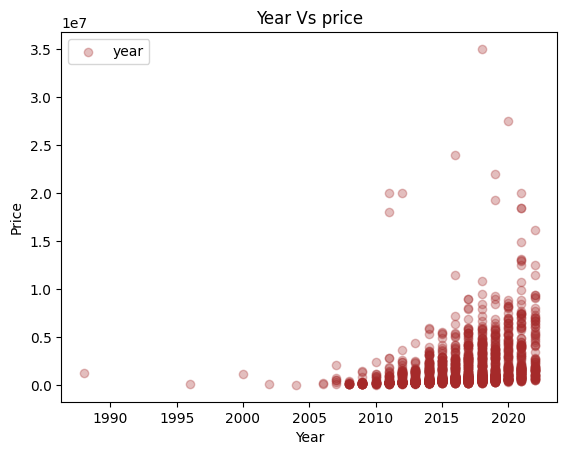

In [361]:
plt.scatter(x=df['Year'],y=df['Price'],alpha=.3,c='brown')
plt.title('Year Vs price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend(['year','price'],loc= 'upper left')
plt.show()

* when the year after 2005 the price also increases and vise-versa

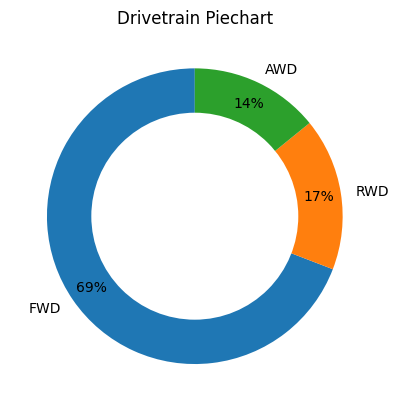

In [362]:
#donut chart
fig,ax = plt.subplots()
ax.pie(x=[1330,321,272],
       startangle=90,
      labels=['FWD','RWD','AWD'],
       autopct ='%.0f%%', pctdistance=0.85, wedgeprops={'width':0.4}
       )

donut= plt.Circle((0,0),0.70,fc='White')
fig = plt.gcf()   #"Give me the current figure."
fig.gca().add_artist(donut)#gca =Get Current Axes
ax.set_title('Drivetrain Piechart')
plt.show()

In [363]:
df['Drivetrain'].value_counts()

,count
Drivetrain,
FWD,1330
RWD,321
AWD,272


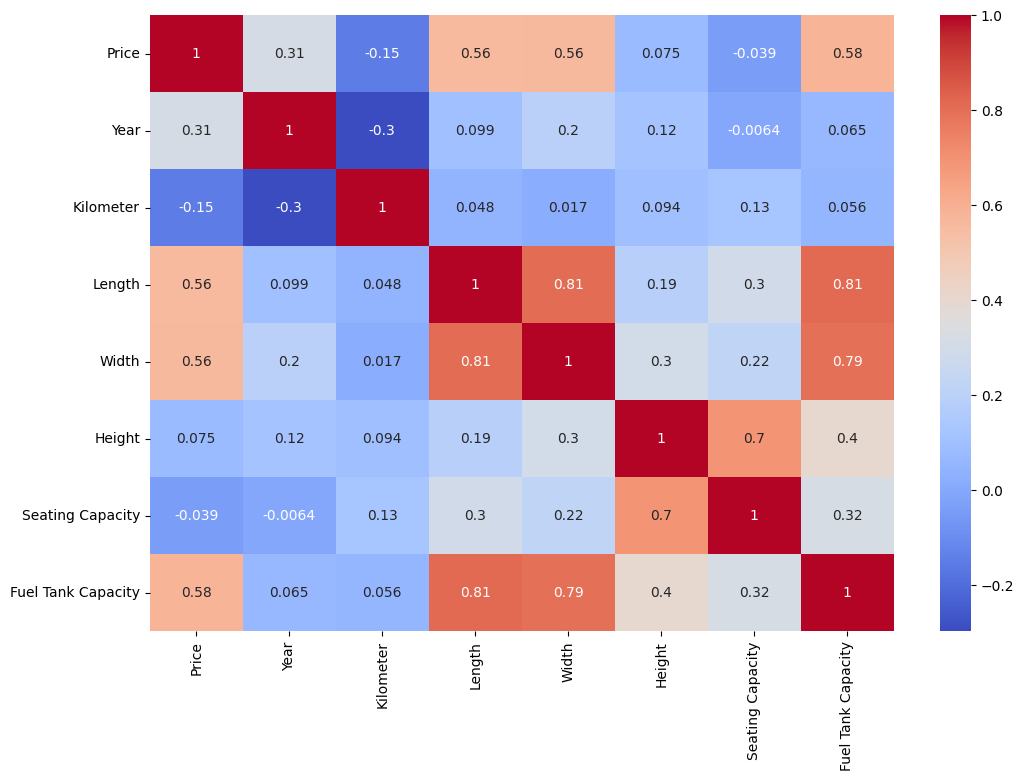

In [364]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

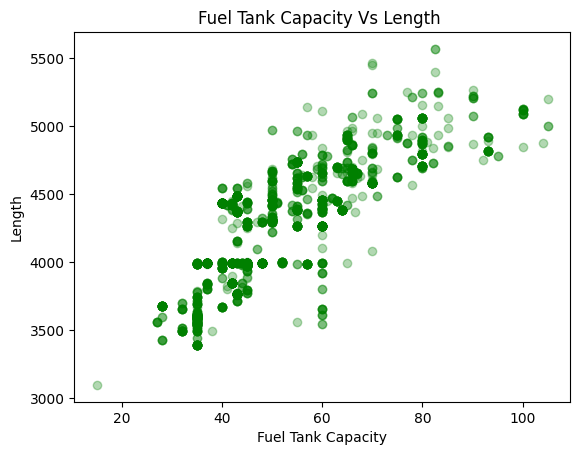

In [365]:
plt.scatter(x=df['Fuel Tank Capacity'],y=df['Length'],alpha=.3,c='green')
plt.title('Fuel Tank Capacity Vs Length ')
plt.xlabel('Fuel Tank Capacity')
plt.ylabel('Length')
#plt.legend(['year','price'],loc= 'upper left')
plt.show()

*  when length of the car increases fuel tank capacity also increases and vise-vesrsa

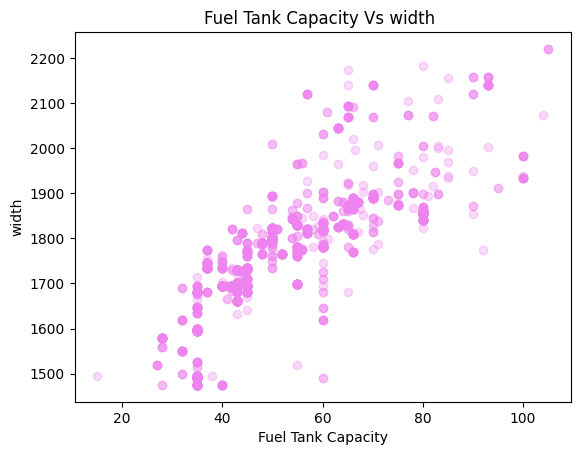

In [366]:
plt.scatter(x=df['Fuel Tank Capacity'],y=df['Width'],alpha=.3,c='violet')
plt.title('Fuel Tank Capacity Vs width ')
plt.xlabel('Fuel Tank Capacity')
plt.ylabel('width')
#plt.legend(['year','price'],loc= 'upper left')
plt.show()

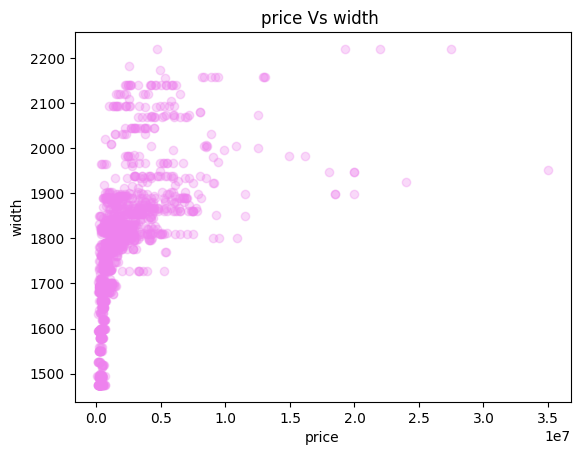

In [367]:
plt.scatter(x=df['Price'],y=df['Width'],alpha=.3,c='violet')
plt.title('price Vs width ')
plt.xlabel('price')
plt.ylabel('width')
#plt.legend(['year','price'],loc= 'upper left')
plt.show()

In [368]:
df['Width'].min()

1475.0

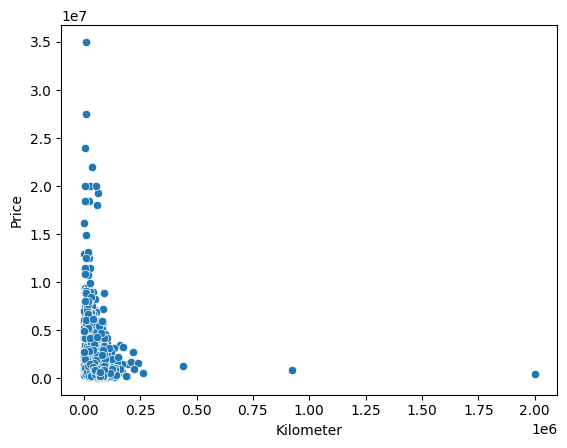

In [369]:
sns.scatterplot(x='Kilometer',
                y='Price',
                data=df)
plt.show()

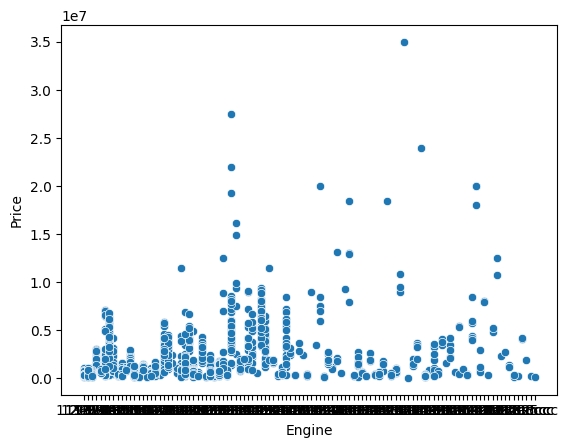

In [370]:
sns.scatterplot(x='Engine',
                y='Price',
                data=df)
plt.show()

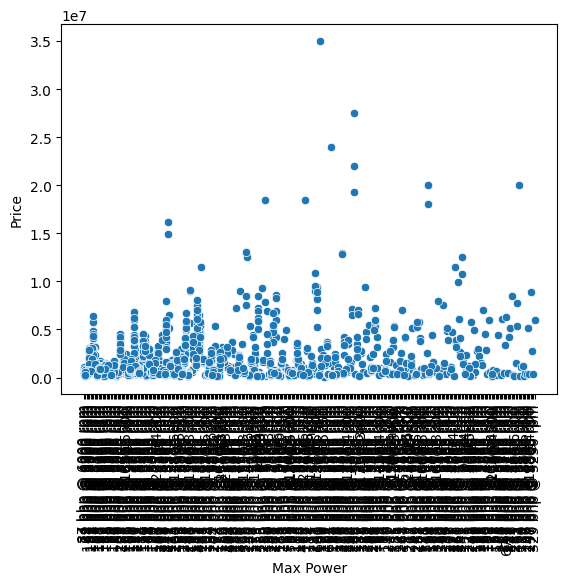

In [371]:
sns.scatterplot(x='Max Power',
                y='Price',
                data=df,)
plt.xticks(rotation=90)
plt.show()

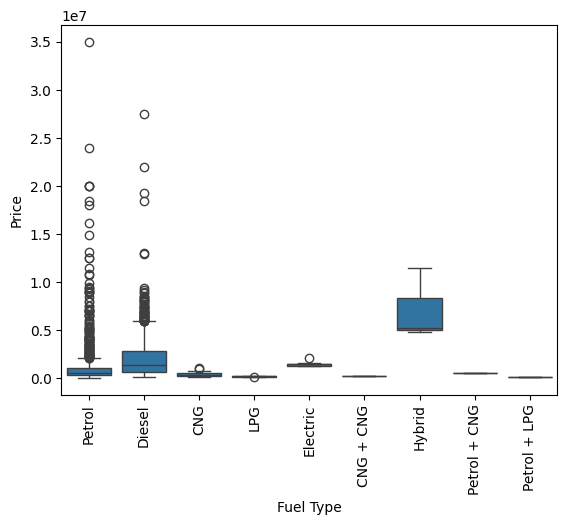

In [372]:
sns.boxplot(x='Fuel Type',
            y='Price',
            data=df)

plt.xticks(rotation=90)
plt.show()

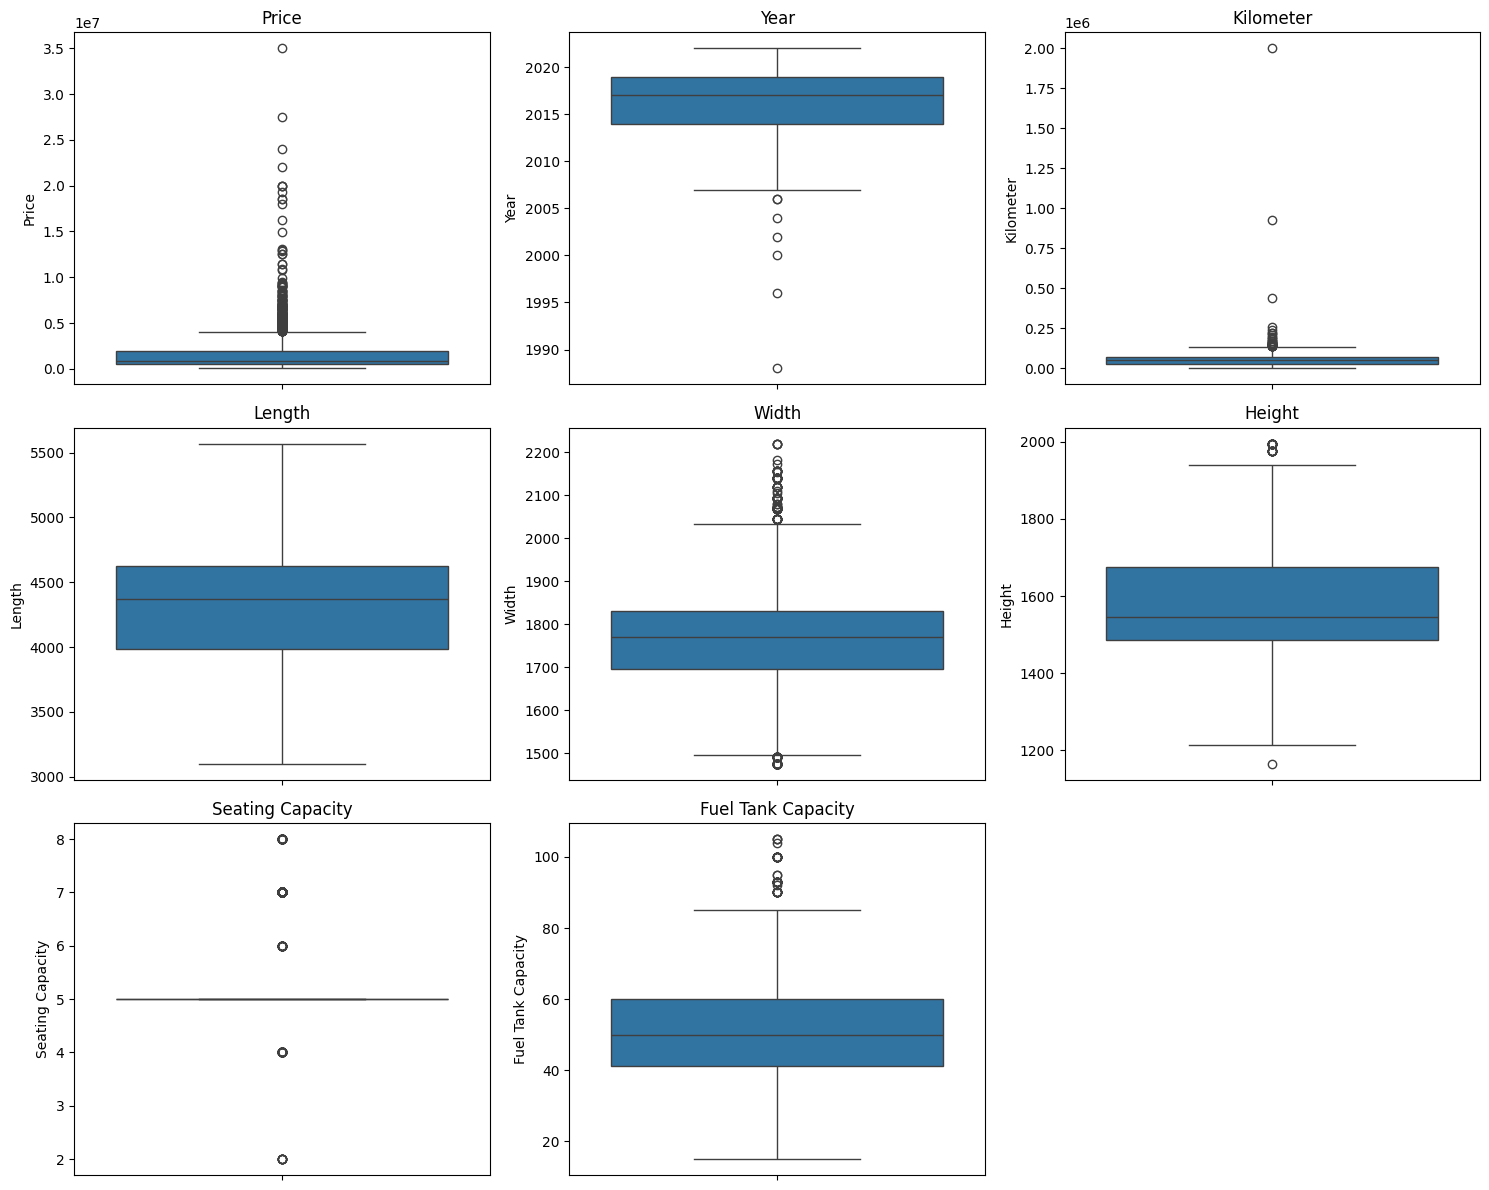

In [373]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'Price',
    'Year',
    'Kilometer',
    'Length',
    'Width',
    'Height',
    'Seating Capacity',
    'Fuel Tank Capacity'
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [374]:
#handling missing value
#numeric col
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_3437/3101722142.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [375]:
#for categorical col
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3437/257374007.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [376]:
df.isna().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [377]:
df.drop('Model', axis=1, inplace=True) #drop model col

In [ ]:
# encoding categorical col

In [378]:
df = pd.get_dummies(df, columns=['Make'], drop_first=True,dtype=int)

In [379]:
df = pd.get_dummies(df, columns=['Fuel Type'], drop_first=True,dtype=int)

In [380]:
df = pd.get_dummies(df, columns=['Transmission'], drop_first=True,dtype=int)

In [381]:
location_freq = df['Location'].value_counts()

df['Location'] = df['Location'].map(location_freq)

In [382]:
df.drop('Color', axis=1, inplace=True)

In [383]:
#df = pd.get_dummies(df, columns=['Color'], drop_first=True,dtype=int)

In [384]:
owner_map = {
    'First': 1,
    'Second': 2,
    'Third': 3,
    'Fourth': 4,
    'UnRegistered Car':5,
    '4 or More': 6
}

df['Owner'] = df['Owner'].replace(owner_map)

/tmp/ipykernel_3437/3470540242.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Owner'] = df['Owner'].replace(owner_map)


In [385]:
df = pd.get_dummies(df, columns=['Seller Type'], drop_first=True,dtype=int)

In [386]:
df['Engine'] = df['Engine'].str.replace(' cc', '', regex=False)
df['Engine'] = df['Engine'].astype(int)

In [387]:
import pandas as pd

# -------- Max Power --------
df['Max_Power_bhp'] = df['Max Power'].str.extract(r'(\d+\.?\d*)')
df['Max_Power_rpm'] = df['Max Power'].str.extract(r'@\s*(\d+)')

# -------- Max Torque --------
df['Max_Torque_Nm'] = df['Max Torque'].str.extract(r'(\d+\.?\d*)')
df['Max_Torque_rpm'] = df['Max Torque'].str.extract(r'@\s*(\d+)')

# Convert all new columns to numeric
cols = ['Max_Power_bhp', 'Max_Power_rpm',
        'Max_Torque_Nm', 'Max_Torque_rpm']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [388]:
df['Engine'].dtype

dtype('int64')

In [389]:
df = pd.get_dummies(df, columns=['Drivetrain'], drop_first=True,dtype=int)

In [390]:
df.head()

,Price,Year,Kilometer,Location,Owner,Engine,Max Power,Max Torque,Length,Width,...,Fuel Type_Petrol + LPG,Transmission_Manual,Seller Type_Corporate,Seller Type_Individual,Max_Power_bhp,Max_Power_rpm,Max_Torque_Nm,Max_Torque_rpm,Drivetrain_FWD,Drivetrain_RWD
0,505000,2017,87150,144,1,1198,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,3990.0,1680.0,...,0,1,1,0,87.0,6000.0,109.0000,4500,1,0
1,450000,2014,75000,47,2,1248,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,3995.0,1695.0,...,0,1,0,1,74.0,4000.0,190.0000,2000,1,0
2,220000,2011,67000,78,1,1197,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,3585.0,1595.0,...,0,1,0,1,79.0,6000.0,112.7619,4000,1,0
3,799000,2019,37500,5,1,1197,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,3995.0,1745.0,...,0,1,0,1,82.0,6000.0,113.0000,4200,1,0
4,1950000,2018,69000,342,1,2393,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,4735.0,1830.0,...,0,1,0,1,148.0,3400.0,343.0000,1400,0,1


In [391]:
df.drop(['Max Power','Max Torque'], axis=1, inplace=True)

In [392]:
df.shape

(2059, 60)

In [393]:
df['Car_Volume'] = df['Length'] * df['Width'] * df['Height']

In [394]:
df.drop(['Length', 'Width', 'Height'], axis=1, inplace=True)

In [395]:
df.head()

,Price,Year,Kilometer,Location,Owner,Engine,Seating Capacity,Fuel Tank Capacity,Make_BMW,Make_Chevrolet,...,Transmission_Manual,Seller Type_Corporate,Seller Type_Individual,Max_Power_bhp,Max_Power_rpm,Max_Torque_Nm,Max_Torque_rpm,Drivetrain_FWD,Drivetrain_RWD,Car_Volume
0,505000,2017,87150,144,1,1198,5.0,35.0,0,0,...,1,1,0,87.0,6000.0,109.0000,4500,1,0,1.008832e+10
1,450000,2014,75000,47,2,1248,5.0,42.0,0,0,...,1,0,1,74.0,4000.0,190.0000,2000,1,0,1.052972e+10
2,220000,2011,67000,78,1,1197,5.0,35.0,0,0,...,1,0,1,79.0,6000.0,112.7619,4000,1,0,8.863016e+09
3,799000,2019,37500,5,1,1197,5.0,37.0,0,0,...,1,0,1,82.0,6000.0,113.0000,4200,1,0,1.052663e+10
4,1950000,2018,69000,342,1,2393,7.0,55.0,0,0,...,1,0,1,148.0,3400.0,343.0000,1400,0,1,1.555376e+10


In [396]:
df.isna().sum()

,0
Price,0
Year,0
Kilometer,0
Location,0
Owner,0
Engine,0
Seating Capacity,0
Fuel Tank Capacity,0
Make_BMW,0
Make_Chevrolet,0


In [397]:
df['Max_Power_rpm'].fillna(df['Max_Power_rpm'].median(),inplace=True)

/tmp/ipykernel_3437/3192120604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Max_Power_rpm'].fillna(df['Max_Power_rpm'].median(),inplace=True)


In [398]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 58 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   2059 non-null   int64  
 1   Year                    2059 non-null   int64  
 2   Kilometer               2059 non-null   int64  
 3   Location                2059 non-null   int64  
 4   Owner                   2059 non-null   int64  
 5   Engine                  2059 non-null   int64  
 6   Seating Capacity        2059 non-null   float64
 7   Fuel Tank Capacity      2059 non-null   float64
 8   Make_BMW                2059 non-null   int64  
 9   Make_Chevrolet          2059 non-null   int64  
 10  Make_Datsun             2059 non-null   int64  
 11  Make_Ferrari            2059 non-null   int64  
 12  Make_Fiat               2059 non-null   int64  
 13  Make_Ford               2059 non-null   int64  
 14  Make_Honda              2059 non-null   

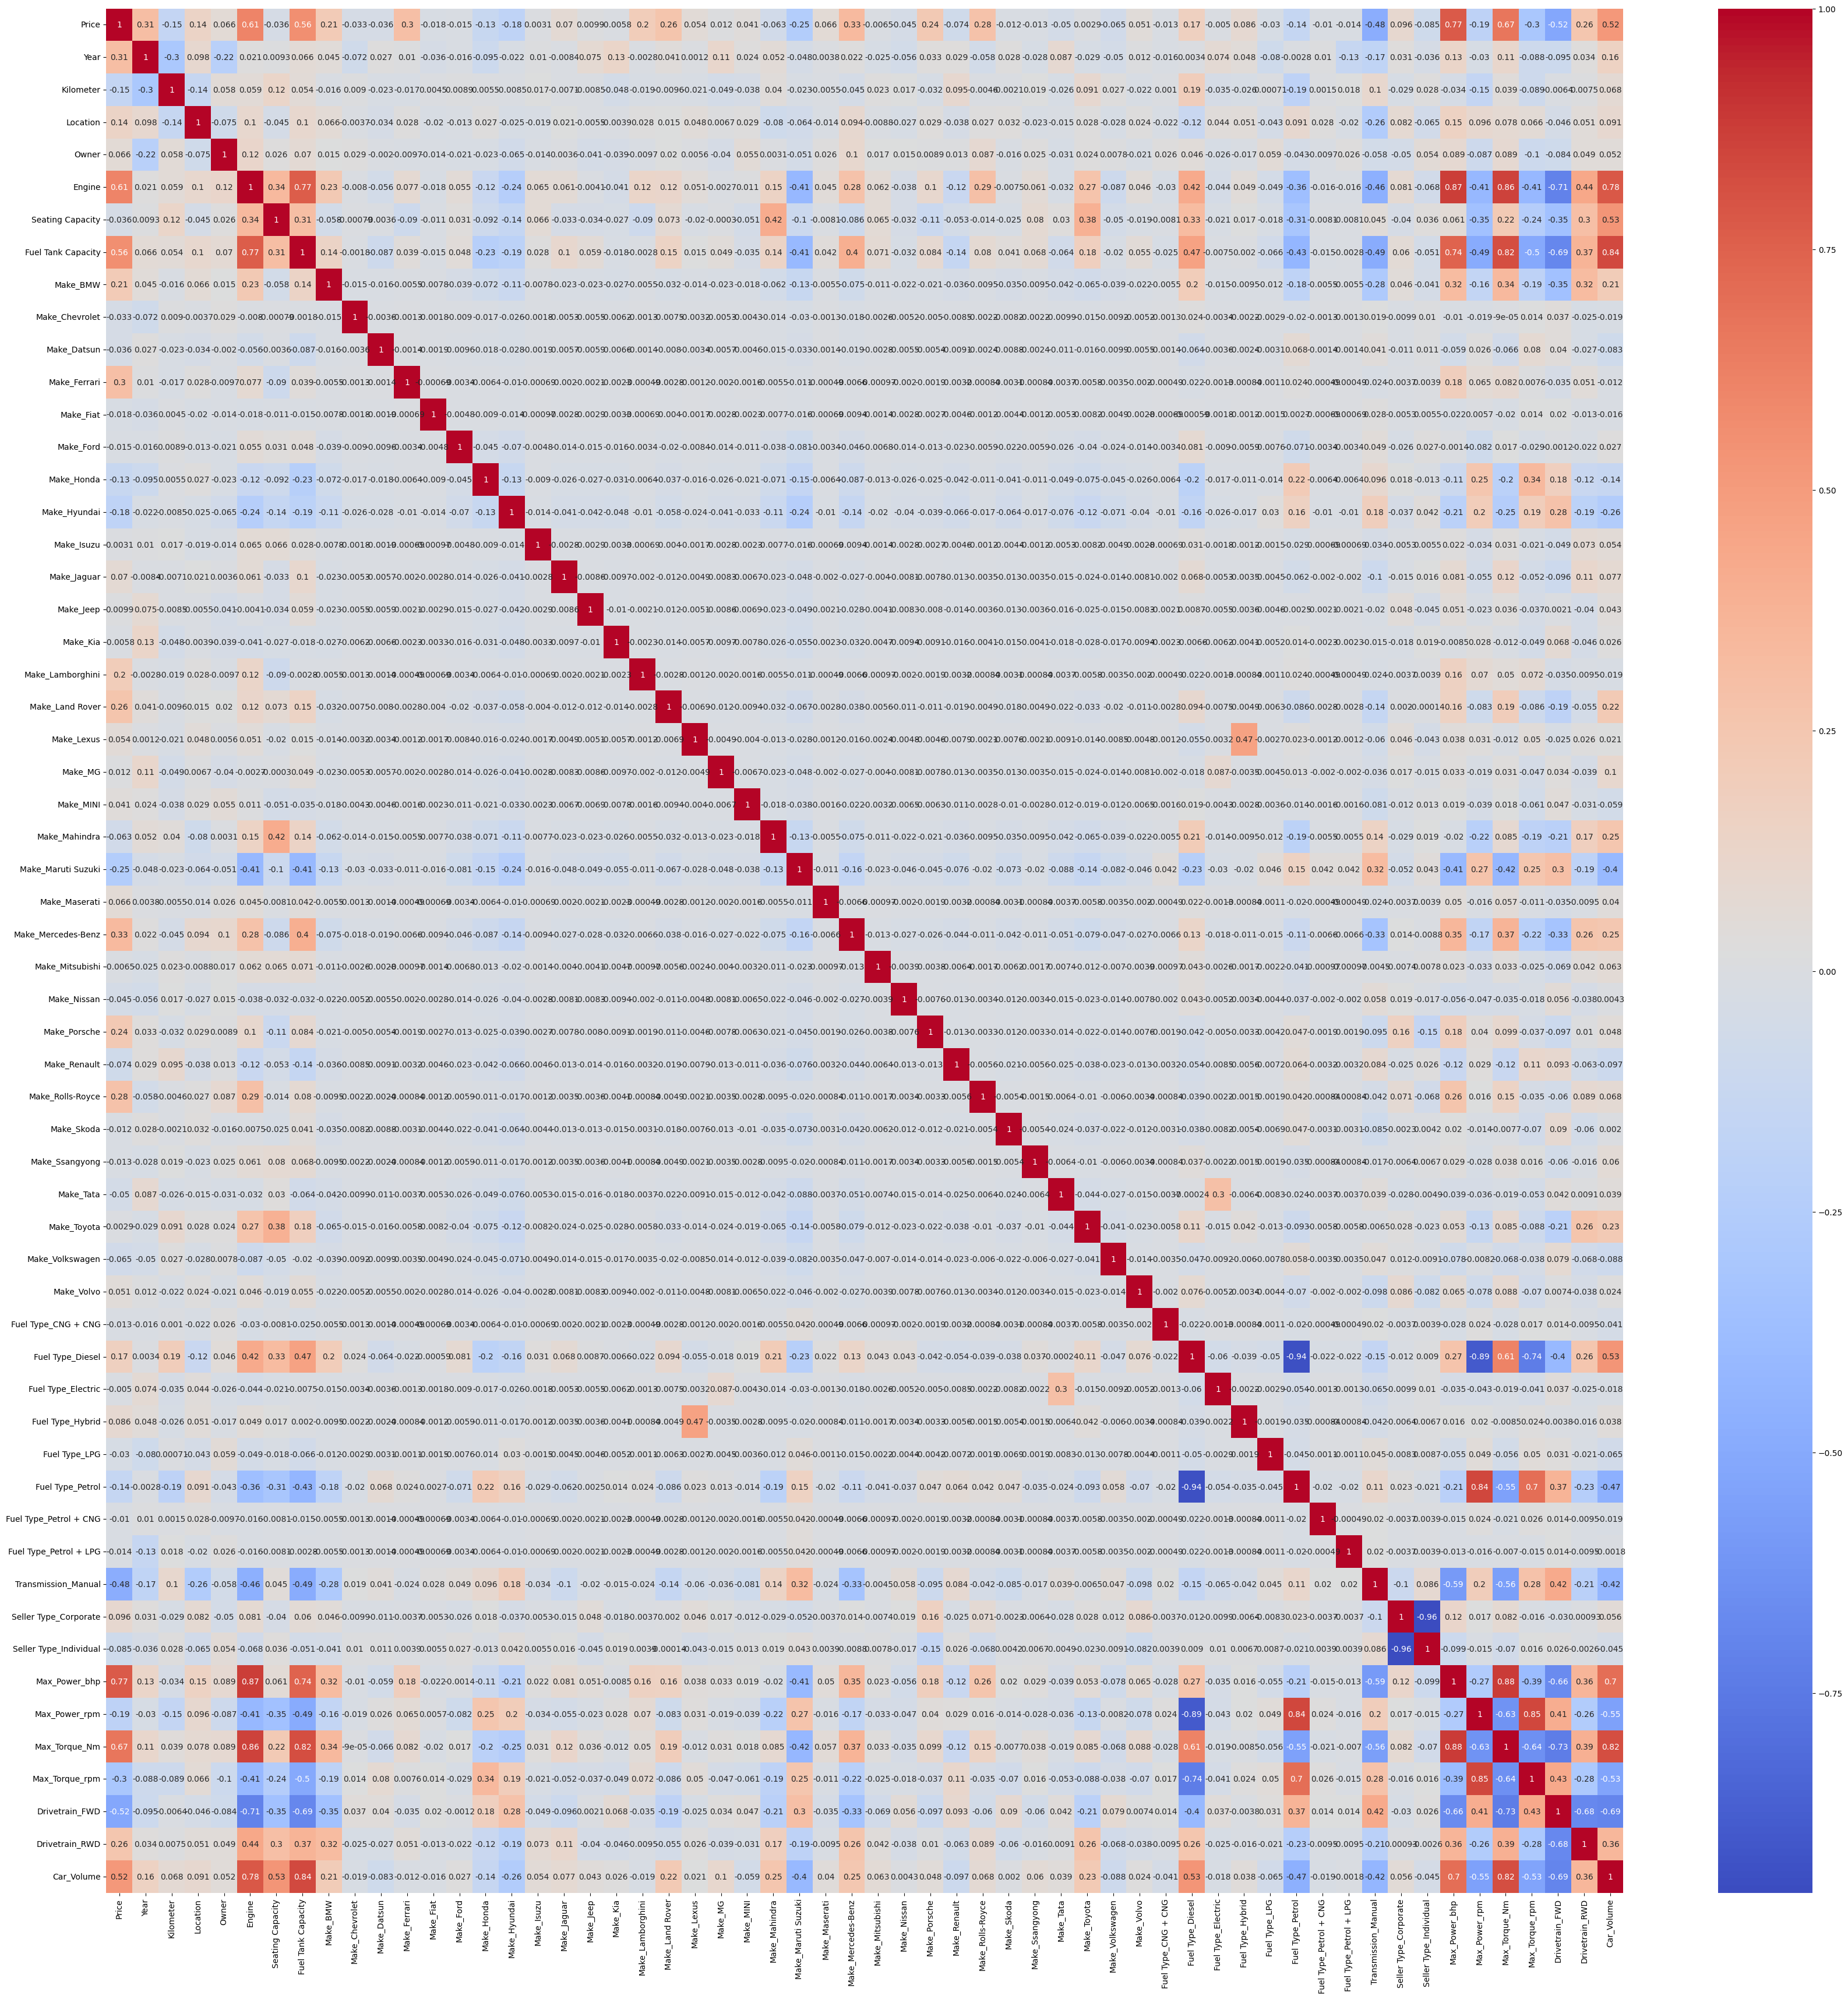

In [399]:
#heatmap
plt.figure(figsize=(42,42))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

###model splitting and scaling

In [400]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# robest scaling
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [401]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1647, 57)
(412, 57)
(1647,)
(412,)


###model selection

In [402]:
#linear regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [403]:
y_pred_lr = lr.predict(X_test)

In [404]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

MAE : 677737.72414865
MSE : 2608441953654.679
RMSE: 1615067.1669174256
R² Score: 0.6266337541157354


In [405]:
result_le = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_lr
})

result_le.head(10)

,Actual,Predicted
1298,4800000,3.995859e+06
591,825000,1.285550e+06
1318,695000,2.268503e+05
1067,950000,1.106278e+06
29,819999,1.038520e+06
1058,310000,-2.695833e+03
712,1000000,1.517272e+06
453,1998999,2.549037e+06
1646,850000,1.777831e+06
757,3950000,3.281782e+06


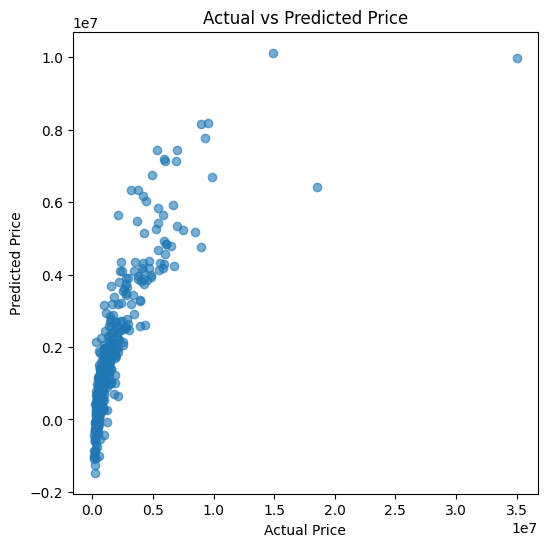

In [406]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

The Linear Regression model achieved an R² score of 0.63, indicating that it explains approximately 63% of the variance in used car prices. The model produced a Mean Absolute Error (MAE) of ₹677,738 and a Root Mean Squared Error (RMSE) of ₹1,615,067, indicating that prediction errors are higher for some vehicles, especially high-priced cars. The scatter plot of actual versus predicted prices shows that the model predicts lower-priced vehicles reasonably well but struggles with expensive vehicles, suggesting that the relationship between the features and price is not entirely linear.$0

In [407]:
#Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt = DecisionTreeRegressor(max_depth=10, random_state=42)

In [408]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [409]:
y_pred_dt = dt.predict(X_test)

In [410]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_df = mean_absolute_error(y_test, y_pred_dt)
mse_df = mean_squared_error(y_test, y_pred_dt)
rmse_df = np.sqrt(mse_df)
r2_df = r2_score(y_test, y_pred_dt)

print("MAE :", mae_df)
print("MSE :", mse_df)
print("RMSE:", rmse_df)
print("R² Score:", r2_df)

MAE : 341876.6610251364
MSE : 963083535955.8064
RMSE: 981368.1959161946
R² Score: 0.8621464879488876


In [411]:
result_dt = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_dt
})

result_dt.head(10)

,Actual,Predicted
1298,4800000,5.275000e+06
591,825000,8.648600e+05
1318,695000,6.344905e+05
1067,950000,1.062294e+06
29,819999,6.344905e+05
1058,310000,3.716304e+05
712,1000000,8.427058e+05
453,1998999,1.255067e+06
1646,850000,1.050000e+06
757,3950000,3.445000e+06


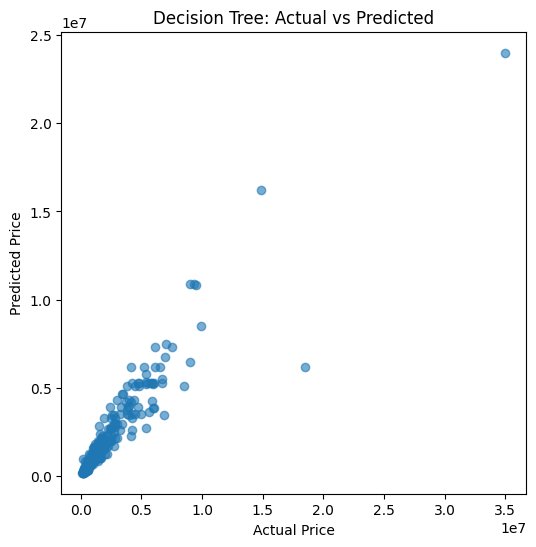

In [412]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_dt, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

In [413]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
50,Max_Power_bhp,0.656725
6,Fuel Tank Capacity,0.113947
0,Year,0.074364
1,Kilometer,0.049671
52,Max_Torque_Nm,0.019452
56,Car_Volume,0.016585
42,Fuel Type_Hybrid,0.014683
27,Make_Mercedes-Benz,0.013385
5,Seating Capacity,0.012056
51,Max_Power_rpm,0.006116


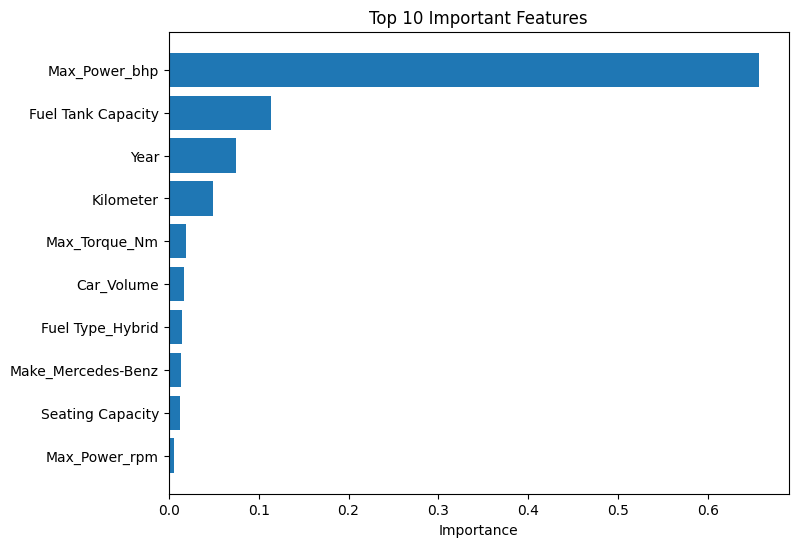

In [414]:
plt.figure(figsize=(8,6))

plt.barh(importance['Feature'][:10], importance['Importance'][:10])

plt.xlabel("Importance")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [415]:
#randomforest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf= r2_score(y_test, y_pred_rf)
mae_rf=mean_absolute_error(y_test, y_pred_rf)
mse_rf=mean_squared_error(y_test, y_pred_rf)
rmse_rf= np.sqrt(mse_rf)
print("R² Score:",r2_rf)
print('mae :' ,mae_rf)
print('mse: ',mse_rf)
print('rmse: ',rmse_rf)

R² Score: 0.8261582386299415
mae : 293246.56765372166
mse:  1214507601191.7998
rmse:  1102047.004982909


In [416]:
result_df= pd.DataFrame({
    'model':['linear regression','DecisionTreeRegressor','Randomforest Regressor'],
    'R2_score':[r2_lr,r2_df,r2_rf],
    'mae':[mae_lr,mae_df,mae_rf],
    'mse':[mse_lr,mse_df,mse_rf],
    'rmse':[rmse_lr,rmse_df,rmse_rf]
})

result_df

,model,R2_score,mae,mse,rmse
0,linear regression,0.626634,677737.724149,2.608442e+12,1.615067e+06
1,DecisionTreeRegressor,0.862146,341876.661025,9.630835e+11,9.813682e+05
2,Randomforest Regressor,0.826158,293246.567654,1.214508e+12,1.102047e+06
